<a href="https://colab.research.google.com/github/jocetapiadev/mi_proyecto/blob/main/Predicci%C3%B3n_de_Precios_de_Veh%C3%ADculos_Usados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📥 PARTE 1: CARGA Y ANÁLISIS EXPLORATORIO DE DATOS
Dataset cargado con éxito. Dimensiones: (1599, 12)

🔍 Primeros registros del dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


✔️ Outliers mitigados en la variable 'total sulfur dioxide' mediante capping por IQR.

📊 Distribución de las Clases de Calidad (0 = Baja, 1 = Alta):
quality_label
1    0.534709
0    0.465291
Name: proportion, dtype: float64

📐 PARTE 2: PREPROCESAMIENTO Y DIVISIÓN
Registros de Entrenamiento: 1279 | Registros de Prueba: 320
✔️ Características físico-químicas escaladas correctamente.

🤖 PARTE 3 Y 4: MODELADO Y EVALUACIÓN DE MÉTRICAS

📋 INFORME DE CLASIFICACIÓN PARA: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       149
           1       0.77      0.74      0.75       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.75      0.74      0.74       320


📋 INFORME DE CLASIFICACIÓN PARA: KNN
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       149
           1       0.81      0.85     

,Modelo,Exactitud (Acc),Precisión,Recall,F1-Score
0,Regresión Logística,0.7438,0.7730,0.7368,0.7545
1,KNN,0.8125,0.8101,0.8480,0.8286
2,Random Forest,0.8063,0.8344,0.7953,0.8144


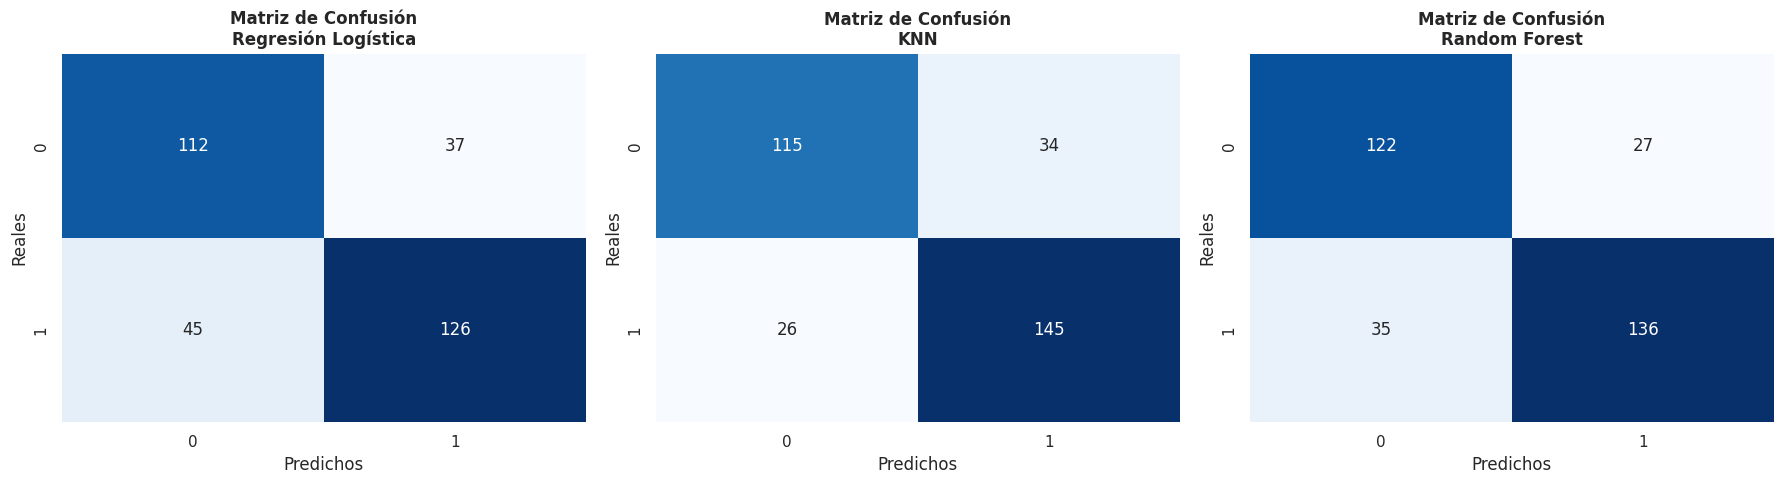

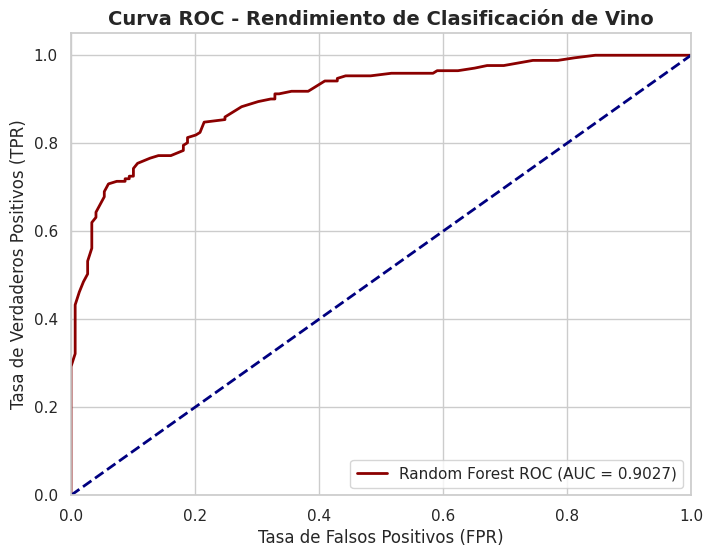

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Preprocesamiento y Validación
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Algoritmos de Clasificación Solicitados
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de Evaluación de Clasificación
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

# Configuración de estilos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# =====================================================================
# PARTE 1: CARGA Y EXPLORACIÓN DE DATOS (EDA)
# =====================================================================
print("="*60)
print("📥 PARTE 1: CARGA Y ANÁLISIS EXPLORATORIO DE DATOS")
print("="*60)

# Importamos el dataset oficial de Vino Tinto desde el repositorio público de UC Irvine
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';') # Este dataset usa punto y coma como separador

print(f"Dataset cargado con éxito. Dimensiones: {df.shape}")
print("\n🔍 Primeros registros del dataset:")
display(df.head())

# --- TRATAMIENTO DE OUTLIERS ---
# El vino tinto suele tener valores extremos en 'total sulfur dioxide'. Aplicamos truncado por IQR.
q1 = df['total sulfur dioxide'].quantile(0.25)
q3 = df['total sulfur dioxide'].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
df['total sulfur dioxide'] = np.where(df['total sulfur dioxide'] > limite_superior, limite_superior, df['total sulfur dioxide'])
print("✔️ Outliers mitigados en la variable 'total sulfur dioxide' mediante capping por IQR.")

# --- CONVERSIÓN A CLASIFICACIÓN BINARIA (Paso crítico de negocio) ---
# Si la calidad es >= 6 es un vino 'Bueno/Alta Calidad' (1), si es menor es 'Regular/Baja Calidad' (0)
df['quality_label'] = (df['quality'] >= 6).astype(int)

print("\n📊 Distribución de las Clases de Calidad (0 = Baja, 1 = Alta):")
print(df['quality_label'].value_counts(normalize=True))

# =====================================================================
# PARTE 2: PREPROCESAMIENTO DE DATOS
# =====================================================================
print("\n" + "="*60)
print("📐 PARTE 2: PREPROCESAMIENTO Y DIVISIÓN")
print("="*60)

# Separamos las características físico-químicas de la etiqueta objetivo
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

# División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Registros de Entrenamiento: {X_train.shape[0]} | Registros de Prueba: {X_test.shape[0]}")

# Escalado de características (Crucial para KNN y Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✔️ Características físico-químicas escaladas correctamente.")

# =====================================================================
# PARTE 3 Y 4: ENTRENAMIENTO, OPTIMIZACIÓN Y EVALUACIÓN DE MODELOS
# =====================================================================
print("\n" + "="*60)
print("🤖 PARTE 3 Y 4: MODELADO Y EVALUACIÓN DE MÉTRICAS")
print("="*60)

# Diccionario para almacenar las mejores versiones de cada modelo
mejores_modelos = {}

# --- 1. Regresión Logística (Optimizada con GridSearch) ---
lr_param = {'C': [0.01, 0.1, 1, 10]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_param, cv=5, scoring='f1')
lr_grid.fit(X_train_scaled, y_train)
mejores_modelos['Regresión Logística'] = lr_grid.best_estimator_

# --- 2. K-Nearest Neighbors (KNN Optimizado) ---
knn_param = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param, cv=5, scoring='f1')
knn_grid.fit(X_train_scaled, y_train)
mejores_modelos['KNN'] = knn_grid.best_estimator_

# --- 3. Random Forest Classifier (Optimizado) ---
rf_param = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param, cv=5, scoring='f1')
rf_grid.fit(X_train_scaled, y_train)
mejores_modelos['Random Forest'] = rf_grid.best_estimator_

# --- Evaluación de los modelos e Informe de Clasificación ---
reportes_metricas = []
matrices_confusion = {}

for nombre, modelo in mejores_modelos.items():
    preds = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    reportes_metricas.append({
        "Modelo": nombre,
        "Exactitud (Acc)": round(acc, 4),
        "Precisión": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

    matrices_confusion[nombre] = confusion_matrix(y_test, preds)

    print(f"\n📋 INFORME DE CLASIFICACIÓN PARA: {nombre.upper()}")
    print(classification_report(y_test, preds))

# Mostrar tabla resumen de Benchmarking
df_reporte = pd.DataFrame(reportes_metricas)
print("\n📊 TABLA COMPARATIVA DE CLASIFICACIÓN:")
display(df_reporte)

# =====================================================================
# VISUALIZACIONES EXIGIDAS: MATRICES DE CONFUSIÓN Y CURVA ROC
# =====================================================================
# Gráfico 1: Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (nombre, matrix) in enumerate(matrices_confusion.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
    axes[idx].set_xlabel('Predichos')
    axes[idx].set_ylabel('Reales')
plt.tight_layout()
plt.show()

# Gráfico 2: Curva ROC del mejor modelo (Random Forest típicamente)
plt.figure(figsize=(8, 6))
best_model = mejores_modelos['Random Forest']
# Obtenemos las probabilidades de la clase positiva (1)
probabilidades = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probabilidades)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkred', lw=2, label=f'Random Forest ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Rendimiento de Clasificación de Vino', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()